# Baseline preprocessing

Denne notebooken gjør den deterministiske preprosesseringen **én gang** og lagrer:
- preprosesserte bilder i en ny mappe
- nye CSV-filer som peker til de preprosesserte bildene

Målet er å flytte crop/resize/reflect-padding ut av treningsløkken, slik at treningsnotebooken kan bli lettere og raskere.

### Imports og maskinvareoppsett

Her brukes kun det som trengs for dataflyt, analyse og eksport. Trenings-, logging- og evalueringskode er bevisst fjernet.

In [1]:

# 0) Imports
from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

tf.config.optimizer.set_jit(False)  # disable XLA autoclustering

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except Exception as e:
        print("Kunne ikke sette memory growth:", e)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-03-13 10:56:19.392147: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 10:56:19.619818: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 10:56:20.416723: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Prosjektstruktur, konstanter og stier

Notebooken antar samme prosjektstruktur som originalnotebooken, og lager i tillegg:
- `datasett_preprocessed_rx/` for ferdige bilder
- `datasplitt_preprocessed_rx/` for nye CSV-er

In [2]:

# 1) Konstanter og prosjektstruktur
SEED = 42
IMG_SIZE = (300, 300)     # Fast utstørrelse på lagrede bilder
SHORT_SIDE = 300          # Beholdes for lesbarhet og samsvar med originalnotebooken

# Navn på nye artefakter
PROCESSED_DATASET_DIRNAME = "datasett_preprocessed"
PROCESSED_SPLIT_DIRNAME = "datasplitt_preprocessed"

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

def find_project_root(start: Path) -> Path:
    # Let oppover fra gjeldende arbeidsmappe til vi finner datasplitt/train.csv
    for p in [start, *start.parents]:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    # Vanlige fallback-lokasjoner
    candidates = [
        Path.home() / "studier" / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
        Path.home() / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
    ]
    for p in candidates:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    raise FileNotFoundError(
        "Fant ikke prosjektrot: forventet datasplitt/train.csv. "
        "Sjekk at datasplitt/ finnes og at du står i riktig repo."
    )

CWD = Path.cwd()
PROJECT_ROOT = find_project_root(CWD)

# Originale splitter
SPLIT_DIR = PROJECT_ROOT / "datasplitt"
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

# Original bildemappe
IMG_ROOT = PROJECT_ROOT / "datasett_src"

# Nye målmapper
PROCESSED_ROOT = PROJECT_ROOT / PROCESSED_DATASET_DIRNAME
PROCESSED_SPLIT_DIR = PROJECT_ROOT / PROCESSED_SPLIT_DIRNAME

print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMG_ROOT:", IMG_ROOT, "exists:", IMG_ROOT.exists())
print("TRAIN_CSV:", TRAIN_CSV, "exists:", TRAIN_CSV.exists())
print("VAL_CSV:", VAL_CSV, "exists:", VAL_CSV.exists())
print("TEST_CSV:", TEST_CSV, "exists:", TEST_CSV.exists())
print("PROCESSED_ROOT:", PROCESSED_ROOT)
print("PROCESSED_SPLIT_DIR:", PROCESSED_SPLIT_DIR)

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

CWD: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/notebooks
PROJECT_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions
IMG_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src exists: True
TRAIN_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/train.csv exists: True
VAL_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/val.csv exists: True
TEST_CSV: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/test.csv exists: True
PROCESSED_ROOT: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed
PROCESSED_SPLIT_DIR: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed


### Les inn datasplittene

Her leses de opprinnelige CSV-filene. Senere i notebooken lagres nye CSV-er som peker til de prosesserte bildene.

In [3]:

# 2) Last split CSV-er
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head())
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())

,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,White,Egenprodusert/non-tesla/dark/IMG_1954.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark
1,Black/Dark gray,Egenprodusert/Tesla/daylight/IMG_1802.jpg,Light,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Light
2,Light gray/Silver,Egenprodusert/Tesla/dark/IMG_3834.jpg,Dark,X,internal,2016–2020,Tesla,X,Tesla|X|Dark
3,Red,Egenprodusert/non-tesla/low-light/IMG_4576.jpg,Medium,Other car,internal,NaN,Other,NaN,Other|NA|Medium
4,Red,Eksternt/non-tesla/daylight/0476_03052.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light


train/val/test: 3766 807 807
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


### Rask inspeksjon av `model`-kolonnen

En enkel sanity check før vi bygger de hierarkiske kolonnene.

In [4]:

print(train_df["model"].astype(str).str.strip().str.lower().value_counts().head(10))

model
other car      2170
y 2020–2024     600
3 2017–2023     241
y 2025-nå       227
x               186
3 2024–nå       172
s 2016–nå        94
s 2012–2015      76
Name: count, dtype: int64


### Analyse av bildeforhold og forventet crop-tap

Denne analysen er nyttig som dokumentasjon på hvor mye informasjon som kan forsvinne ved square crop-strategien.

In [5]:

def aspect_stats(df: pd.DataFrame, name: str) -> dict:
    rel = df["image"].astype(str).tolist()
    abs_paths = [str(IMG_ROOT / p) for p in rel]

    exists = [p for p in abs_paths if os.path.exists(p)]
    missing = len(abs_paths) - len(exists)

    n = square = portrait = landscape = 0
    crop_fracs = []

    for p in exists:
        try:
            with Image.open(p) as im:
                w, h = im.size
        except Exception:
            continue

        n += 1
        if h == w:
            square += 1
            crop_fracs.append(0.0)
            continue

        if h > w:
            portrait += 1
        else:
            landscape += 1

        r = max(h, w) / min(h, w)
        crop_fracs.append((r - 1.0) / r)

    if n == 0:
        return {
            "split": name,
            "total_i_csv": len(abs_paths),
            "missing_files": missing,
            "checked": 0,
            "square": 0,
            "non_square": 0,
            "portrait": 0,
            "landscape": 0,
            "avg_crop_%": np.nan,
            "p50_crop_%": np.nan,
            "p90_crop_%": np.nan,
            "max_crop_%": np.nan,
        }

    cf = np.array(crop_fracs, dtype=float)
    return {
        "split": name,
        "total_i_csv": len(abs_paths),
        "missing_files": missing,
        "checked": n,
        "square": square,
        "non_square": n - square,
        "portrait": portrait,
        "landscape": landscape,
        "avg_crop_%": float(cf.mean() * 100.0),
        "p50_crop_%": float(np.quantile(cf, 0.50) * 100.0),
        "p90_crop_%": float(np.quantile(cf, 0.90) * 100.0),
        "max_crop_%": float(cf.max() * 100.0),
    }

stats = [
    aspect_stats(train_df, "train"),
    aspect_stats(val_df, "val"),
    aspect_stats(test_df, "test"),
    aspect_stats(pd.concat([train_df, val_df, test_df], ignore_index=True), "ALL"),
]

stats_df = pd.DataFrame(stats)
display(stats_df)

,split,total_i_csv,missing_files,checked,square,non_square,portrait,landscape,avg_crop_%,p50_crop_%,p90_crop_%,max_crop_%
0,train,3766,0,3766,1444,2322,701,1621,18.658732,25.0,37.942708,75.055679
1,val,807,0,807,310,497,142,355,18.906707,25.0,38.757340,66.666667
2,test,807,0,807,332,475,136,339,17.825589,25.0,37.676056,69.696970
3,ALL,5380,0,5380,2086,3294,979,2315,18.570957,25.0,38.000000,75.055679


### Bygg og valider hierarkiske kolonner

Denne delen beholdes fra originalnotebooken slik at de nye CSV-filene blir klare for treningsnotebooken.

In [6]:

# 3) Bygg/valider hierarki-kolonner (idempotent: ok om de allerede finnes)
def ensure_hierarchy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["image", "model", "lighting"]:
        if c not in out.columns:
            raise KeyError(f"Mangler kolonne '{c}' i split-CSV. Fant: {out.columns.tolist()}")

    out["model"] = out["model"].astype("string")
    out["lighting"] = out["lighting"].astype("string")

    # lvl1: Tesla vs Other  (matcher både "Other" og "Other car")
    model_norm = out["model"].fillna("").str.strip().str.lower()
    is_other = model_norm.str.startswith("other")
    out["lvl1"] = np.where(is_other, "Other", "Tesla")

    # lvl2: kun for Tesla, ellers NA
    out["lvl2"] = out["model"].where(out["lvl1"].eq("Tesla"), pd.NA)

    # sample weight lvl2: kun Tesla
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    return out

train_df = ensure_hierarchy(train_df)
val_df   = ensure_hierarchy(val_df)
test_df  = ensure_hierarchy(test_df)

print("lvl1 counts (train):\n", train_df["lvl1"].value_counts())
print("\nlvl2 counts (train):\n", train_df["lvl2"].value_counts().head(20))
print("\nlighting counts (train):\n", train_df["lighting"].value_counts())

lvl1 counts (train):
 lvl1
Other    2170
Tesla    1596
Name: count, dtype: int64

lvl2 counts (train):
 lvl2
Y 2020–2024    600
3 2017–2023    241
Y 2025-nå      227
X              186
3 2024–nå      172
S 2016–nå       94
S 2012–2015     76
Name: count, dtype: Int64

lighting counts (train):
 lighting
Light     2068
Medium     852
Dark       846
Name: count, dtype: Int64


### Label-encoding og sample weights

Dette gjør at de prosesserte CSV-ene allerede inneholder label-kolonnene som treningsnotebooken trenger.

In [7]:

# lvl1: Other=0, Tesla=1 (fast)
lvl1_map = {"Other": 0, "Tesla": 1}

# lvl2: kun Tesla-klasser (fra train)
lvl2_classes = sorted(
    train_df.loc[train_df["lvl1"].eq("Tesla"), "lvl2"]
      .astype("string")
      .dropna()
      .unique()
      .tolist()
)
lvl2_to_id = {c: i for i, c in enumerate(lvl2_classes)}
num_lvl2 = len(lvl2_classes)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

def add_encoded(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["y_lvl1"] = out["lvl1"].map(lvl1_map).astype(np.int32)
    out["w_lvl1"] = 1.0
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    # dummy 0 for Other (maskeres bort med w_lvl2=0)
    y2 = np.zeros(len(out), dtype=np.int32)
    tesla_mask = out["lvl1"].eq("Tesla").to_numpy()

    mapped = out.loc[tesla_mask, "lvl2"].map(lvl2_to_id)
    if mapped.isna().any():
        bad = out.loc[tesla_mask & mapped.isna(), "lvl2"].astype(str).unique()[:20]
        raise ValueError(f"Tesla-rader med ukjent lvl2 (ikke i train mapping): {bad}")

    y2[tesla_mask] = mapped.astype(np.int32).to_numpy()
    out["y_lvl2"] = y2

    return out

train_df = add_encoded(train_df)
val_df   = add_encoded(val_df)
test_df  = add_encoded(test_df)

display(train_df[["image", "lvl1", "lvl2", "lighting", "y_lvl1", "y_lvl2", "w_lvl2"]].head())

Antall lvl2-klasser: 7
Eksempel lvl2-klasser: ['3 2017–2023', '3 2024–nå', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


,image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,Egenprodusert/non-tesla/dark/IMG_1954.jpg,Other,<NA>,Dark,0,0,0.0
1,Egenprodusert/Tesla/daylight/IMG_1802.jpg,Tesla,3 2017–2023,Light,1,0,1.0
2,Egenprodusert/Tesla/dark/IMG_3834.jpg,Tesla,X,Dark,1,4,1.0
3,Egenprodusert/non-tesla/low-light/IMG_4576.jpg,Other,<NA>,Medium,0,0,0.0
4,Eksternt/non-tesla/daylight/0476_03052.jpg,Other,<NA>,Light,0,0,0.0


### Sanity check av filstier

En liten kontroll før eksporten starter.

In [8]:

sample_paths = [str(IMG_ROOT / p) for p in train_df["image"].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/non-tesla/dark/IMG_1954.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/daylight/IMG_1802.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/dark/IMG_3834.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/non-tesla/low-light/IMG_4576.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/non-tesla/daylight/0476_03052.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/dark/IMG_3856.jpg
True /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/E

### Bildepreprosessering

Samme hovedidé som i originalnotebooken:
- portrait/square: resize på korteste side + center crop
- landscape: hybrid crop + reflect padding

Dekodingen er gjort litt mer robust ved å bruke `tf.io.decode_image`, slik at både JPEG og PNG kan leses inn før alt lagres videre som JPEG.

In [9]:

def _center_crop_after_resize_short_side(img: tf.Tensor, target: int) -> tf.Tensor:
    """Bevar aspect ratio, skaler slik at korteste side = target, så center-crop til target x target."""
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)

    scale = tf.cast(target, tf.float32) / tf.minimum(h, w)
    new_h = tf.cast(tf.math.ceil(h * scale), tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)

    img = tf.image.resize(img, [new_h, new_w], antialias=True, method="bilinear")
    img = tf.image.resize_with_crop_or_pad(img, target, target)
    return img

def _hybrid_crop_reflect_landscape(
    img: tf.Tensor,
    target: int,
    crop_fraction_of_excess: float = 0.5,
) -> tf.Tensor:
    """
    Landscape hybrid:
    1) Skaler slik at høyden = target
    2) Crop bort en andel av overskuddsbredden
    3) Reskaler deretter hele bildet slik at bredden = target
    4) Reflect-pad høyden opp til target
    """
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)

    # Steg 1: skaler slik at høyden blir target
    scale = tf.cast(target, tf.float32) / h
    new_h = tf.cast(target, tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)
    new_w = tf.maximum(new_w, 1)

    img = tf.image.resize(img, [new_h, new_w], antialias=True, method="bilinear")

    # Steg 2: crop bort en andel av overskuddsbredden
    excess_w = tf.maximum(new_w - target, 0)
    crop_total = tf.cast(
        tf.round(tf.cast(excess_w, tf.float32) * crop_fraction_of_excess),
        tf.int32
    )

    crop_left = crop_total // 2
    crop_right = crop_total - crop_left

    img = tf.cond(
        crop_total > 0,
        lambda: img[:, crop_left:new_w - crop_right, :],
        lambda: img
    )

    # Oppdater shape etter crop
    cropped_shape = tf.shape(img)
    cropped_h = cropped_shape[0]
    cropped_w = cropped_shape[1]

    # Steg 3: reskaler hele bildet slik at bredden blir target
    scale2 = tf.cast(target, tf.float32) / tf.cast(cropped_w, tf.float32)
    resized_h = tf.cast(tf.math.round(tf.cast(cropped_h, tf.float32) * scale2), tf.int32)
    resized_h = tf.maximum(resized_h, 1)

    img = tf.image.resize(img, [resized_h, target], antialias=True, method="bilinear")

    # Steg 4: reflect-pad høyden opp til target
    pad_h = target - resized_h
    top = pad_h // 2
    bottom = pad_h - top

    can_reflect = tf.logical_and(top < resized_h, bottom < resized_h)

    img = tf.cond(
        pad_h > 0,
        lambda: tf.cond(
            can_reflect,
            lambda: tf.pad(img, [[top, bottom], [0, 0], [0, 0]], mode="REFLECT"),
            lambda: tf.pad(img, [[top, bottom], [0, 0], [0, 0]], mode="CONSTANT", constant_values=0.0),
        ),
        lambda: img
    )

    return img

def decode_any_image(path: tf.Tensor) -> tf.Tensor:
    """Les bilde robust (JPEG/PNG), returner float32 i [0,1]."""
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img.set_shape([None, None, 3])
    return img

def decode_and_preprocess(path: tf.Tensor) -> tf.Tensor:
    target = IMG_SIZE[0]
    img = decode_any_image(path)

    shape = tf.shape(img)
    h = shape[0]
    w = shape[1]

    img = tf.cond(
        h >= w,
        lambda: _center_crop_after_resize_short_side(img, target),
        lambda: _hybrid_crop_reflect_landscape(img, target, crop_fraction_of_excess=0.5),
    )

    img = tf.ensure_shape(img, [target, target, 3])
    return img

### Visualiser et lite utvalg preprocessede treningsbilder

Denne cellen er kun for visuell kontroll før eksport.

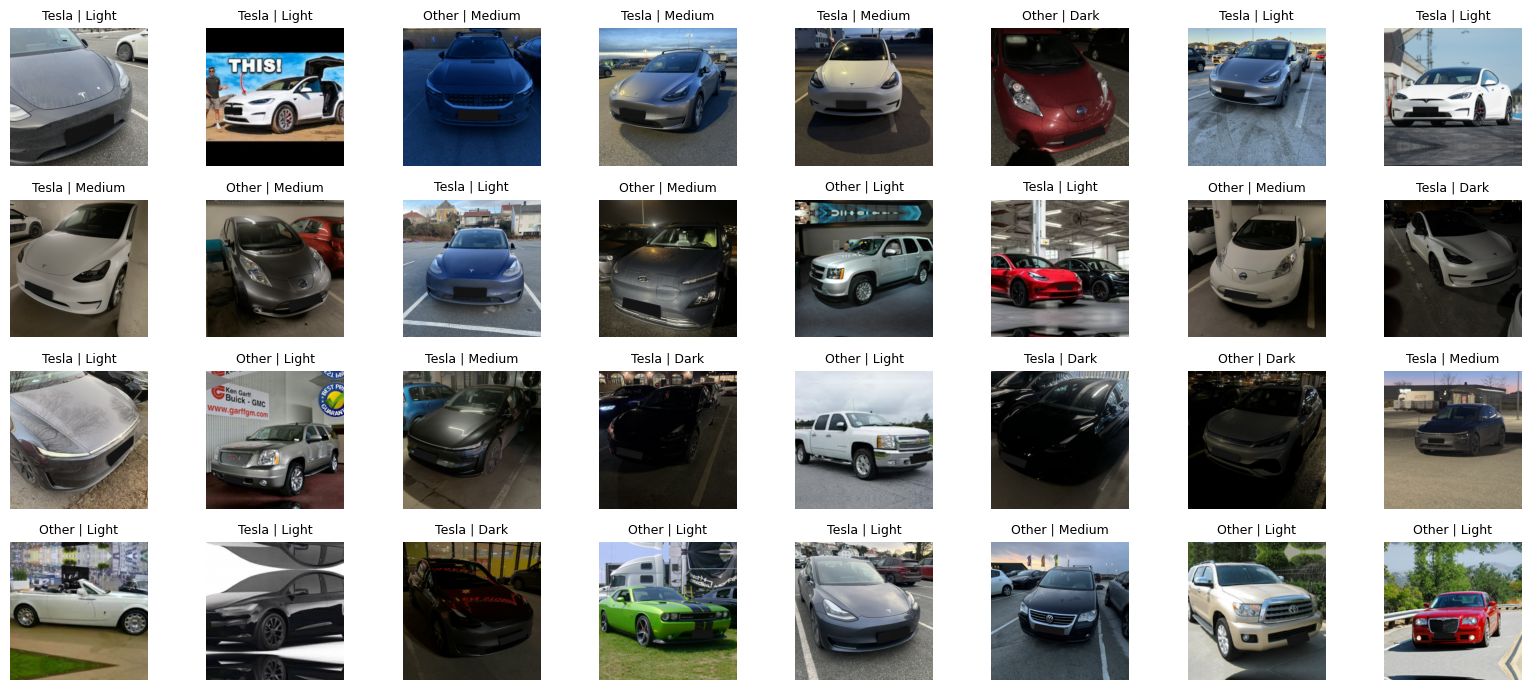

In [17]:

def show_preprocessed_examples(df: pd.DataFrame, n: int = 16, seed: int = 42):
    sample_df = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    fig, axes = plt.subplots(4, int(np.ceil(len(sample_df) / 4)), figsize=(16, 7))
    axes = np.array(axes).reshape(-1)

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        p = IMG_ROOT / str(row["image"])
        img = decode_and_preprocess(tf.constant(str(p))).numpy()
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(f'{row["lvl1"]} | {row["lighting"]}', fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_preprocessed_examples(train_df, n=32, seed=SEED)

### Opprett mapper for prosesserte bilder og nye CSV-er

Originaldataene beholdes urørt. Denne notebooken lager en ny "etter"-mappe med ferdige bildefiler.

In [18]:

PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
PROCESSED_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

for split_name in ["train", "val", "test"]:
    (PROCESSED_ROOT / split_name).mkdir(parents=True, exist_ok=True)

print("Klar for eksport til:")
print(PROCESSED_ROOT)
print(PROCESSED_SPLIT_DIR)

Klar for eksport til:
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed


### Eksporter preprosesserte bilder

Hvert bilde:
- leses fra original datasettmappe
- preprocesses deterministisk
- lagres som JPEG i ny mappe
- registreres i en ny kolonne `processed_image`

Bildefilene lagres med samme relative mappestruktur som originalene, men under `train/`, `val/` og `test/`.

In [19]:

def save_preprocessed_split(
    df: pd.DataFrame,
    split_name: str,
    overwrite: bool = False,
    jpeg_quality: int = 95,
) -> pd.DataFrame:
    out_df = df.copy()
    processed_rel_paths = []
    missing_or_failed = []

    split_out_dir = PROCESSED_ROOT / split_name
    split_out_dir.mkdir(parents=True, exist_ok=True)

    for rel_path in tqdm(out_df["image"].astype(str).tolist(), desc=f"Prosesserer {split_name}"):
        src_path = IMG_ROOT / rel_path

        # Behold mappestrukturen fra originalfilen, men lagre under ny split-mappe som JPG
        rel_no_suffix = Path(rel_path).with_suffix("")
        dst_rel = Path(split_name) / rel_no_suffix.with_suffix(".jpg")
        dst_path = PROCESSED_ROOT / dst_rel
        dst_path.parent.mkdir(parents=True, exist_ok=True)

        try:
            if overwrite or not dst_path.exists():
                img = decode_and_preprocess(tf.constant(str(src_path))).numpy()
                img = np.clip(img * 255.0, 0, 255).astype(np.uint8)
                Image.fromarray(img).save(dst_path, format="JPEG", quality=jpeg_quality)

            processed_rel_paths.append(str(dst_rel).replace("\\", "/"))

        except Exception as e:
            missing_or_failed.append((str(src_path), repr(e)))
            processed_rel_paths.append(pd.NA)

    out_df["processed_image"] = processed_rel_paths

    if missing_or_failed:
        fail_df = pd.DataFrame(missing_or_failed, columns=["source_path", "error"])
        fail_csv = PROCESSED_SPLIT_DIR / f"{split_name}_failed_files.csv"
        fail_df.to_csv(fail_csv, index=False)
        print(f"[{split_name}] Feil eller manglende filer: {len(missing_or_failed)}")
        print(f"[{split_name}] Feillogg lagret til: {fail_csv}")
    else:
        print(f"[{split_name}] Alle filer prosessert uten registrerte feil.")

    return out_df

### Kjør eksporten

Denne cellen kan ta tid fordi hele datasettet prosesseres og lagres på nytt. Når den er kjørt ferdig én gang, skal treningsnotebooken kunne lese de ferdige bildene direkte.

In [20]:

train_processed_df = save_preprocessed_split(train_df, "train", overwrite=False)
val_processed_df   = save_preprocessed_split(val_df, "val", overwrite=False)
test_processed_df  = save_preprocessed_split(test_df, "test", overwrite=False)

Prosesserer train:   0%|          | 0/3766 [00:00<?, ?it/s]

[train] Alle filer prosessert uten registrerte feil.


Prosesserer val:   0%|          | 0/807 [00:00<?, ?it/s]

[val] Alle filer prosessert uten registrerte feil.


Prosesserer test:   0%|          | 0/807 [00:00<?, ?it/s]

[test] Alle filer prosessert uten registrerte feil.


### Lagre nye CSV-er

De nye CSV-filene peker til de prosesserte bildene og beholder label-kolonnene som treningsnotebooken trenger.

In [21]:

train_processed_csv = PROCESSED_SPLIT_DIR / "train_processed.csv"
val_processed_csv   = PROCESSED_SPLIT_DIR / "val_processed.csv"
test_processed_csv  = PROCESSED_SPLIT_DIR / "test_processed.csv"

train_processed_df.to_csv(train_processed_csv, index=False)
val_processed_df.to_csv(val_processed_csv, index=False)
test_processed_df.to_csv(test_processed_csv, index=False)

print("Lagret:")
print(train_processed_csv)
print(val_processed_csv)
print(test_processed_csv)

display(train_processed_df.head())

Lagret:
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/train_processed.csv
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/val_processed.csv
/home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt_preprocessed/test_processed.csv


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key,w_lvl2,y_lvl1,w_lvl1,y_lvl2,processed_image
0,White,Egenprodusert/non-tesla/dark/IMG_1954.jpg,Dark,Other car,internal,NaN,Other,<NA>,Other|NA|Dark,0.0,0,1.0,0,train/Egenprodusert/non-tesla/dark/IMG_1954.jpg
1,Black/Dark gray,Egenprodusert/Tesla/daylight/IMG_1802.jpg,Light,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Light,1.0,1,1.0,0,train/Egenprodusert/Tesla/daylight/IMG_1802.jpg
2,Light gray/Silver,Egenprodusert/Tesla/dark/IMG_3834.jpg,Dark,X,internal,2016–2020,Tesla,X,Tesla|X|Dark,1.0,1,1.0,4,train/Egenprodusert/Tesla/dark/IMG_3834.jpg
3,Red,Egenprodusert/non-tesla/low-light/IMG_4576.jpg,Medium,Other car,internal,NaN,Other,<NA>,Other|NA|Medium,0.0,0,1.0,0,train/Egenprodusert/non-tesla/low-light/IMG_45...
4,Red,Eksternt/non-tesla/daylight/0476_03052.jpg,Light,Other car,external,NaN,Other,<NA>,Other|NA|Light,0.0,0,1.0,0,train/Eksternt/non-tesla/daylight/0476_03052.jpg


### Enkel validering av de lagrede filene

Her kontrolleres:
- at `processed_image` finnes
- at noen eksempelbilder faktisk ligger på disk
- at et prosessert bilde har forventet størrelse

In [22]:

assert "processed_image" in train_processed_df.columns
assert train_processed_df["processed_image"].notna().all(), "Noen train-bilder ble ikke prosessert."
assert val_processed_df["processed_image"].notna().all(), "Noen val-bilder ble ikke prosessert."
assert test_processed_df["processed_image"].notna().all(), "Noen test-bilder ble ikke prosessert."

sample_processed = PROCESSED_ROOT / str(train_processed_df["processed_image"].dropna().iloc[0])
print("Eksempelfil:", sample_processed, "exists:", sample_processed.exists())

with Image.open(sample_processed) as im:
    print("Lagret størrelse:", im.size)

Eksempelfil: /home/andre-kidess/studier/DAT191/visual-vehicle-recognition-varying-lighting-conditions/datasett_preprocessed/train/Egenprodusert/non-tesla/dark/IMG_1954.jpg exists: True
Lagret størrelse: (300, 300)
